## Deep Learning

Content

- Introduction
- Fundamental concepts in interaction with Torch
- Design, training, and learning of a simple neural network

### Introduction
Basic explanation of a neural network model in Keras: https://towardsdatascience.com/building-a-deep-learning-model-using-keras-1548ca149d37.

The operations during training and usage of neural networks are done on matrices. Thus, you should be familiar with the necessary concepts of Linear Algebra.

If you need a brush up:
- https://www.youtube.com/watch?v=fNk_zzaMoSs&list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab
- https://www.youtube.com/watch?v=7UJ4CFRGd-U&list=PLE7DDD91010BC51F8

### Neural Networks
You find a basic explanation of Neural Network models in Keras here:
- https://towardsdatascience.com/building-a-deep-learning-model-using-keras-1548ca149d37

### Single-Layer Perceptron

A Single-Layer Perceptron (SLP) is the simplest type of artificial neural network. It contains an input layer and a single output layer, with no hidden layer.

The perceptron calculates a weighted sum of the inputs and applies a step activation function to produce a binary output.

For this notebook, we will use the Iris dataset, a well-known public dataset available through scikit-learn.

To keep the example suitable for a single-layer perceptron, we will perform binary classification:

1. Iris Setosa → 0
2. Iris Versicolor → 1

We will use two features so that students can also visualize the learned decision boundary.

### 1. Import Required Libraries

In [ ]:
# ============================================================
# SINGLE-LAYER PERCEPTRON
# Binary Classification using the Iris Dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

### 2. Load the Public Dataset

The Iris dataset contains measurements of iris flowers.

Each sample has four features:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

There are three classes:

```
0 -> Setosa
1 -> Versicolor
2 -> Virginica
```

In [ ]:
# Load the Iris dataset
iris = load_iris()

# Features
X = iris.data

# Target labels
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:", iris.target_names)

Feature shape: (150, 4)
Target shape: (150,)
Class names: ['setosa' 'versicolor' 'virginica']


### 3. Select Two Classes

A basic perceptron is a binary classifier, so we will use only:

```
Setosa       -> 0
Versicolor   -> 1
```

We will remove Virginica samples.

In [ ]:
# Select only Setosa and Versicolor
binary_mask = y < 2

X = X[binary_mask]
y = y[binary_mask]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nClasses:")
print(np.unique(y))

Feature shape: (100, 4)
Target shape: (100,)

Classes:
[0 1]


### 4. Select Two Features

For visualization, we will use only two features:

- Sepal length
- Petal length

In [ ]:
# Feature indices:
# 0 -> sepal length
# 1 -> sepal width
# 2 -> petal length
# 3 -> petal width

X = X[:, [0, 2]]

print("X shape:", X.shape)

X shape: (100, 2)


Now each sample looks like:

```
[sepal length, petal length]
```

### 5. Visualize the Dataset

Before training the model, let's look at the data.

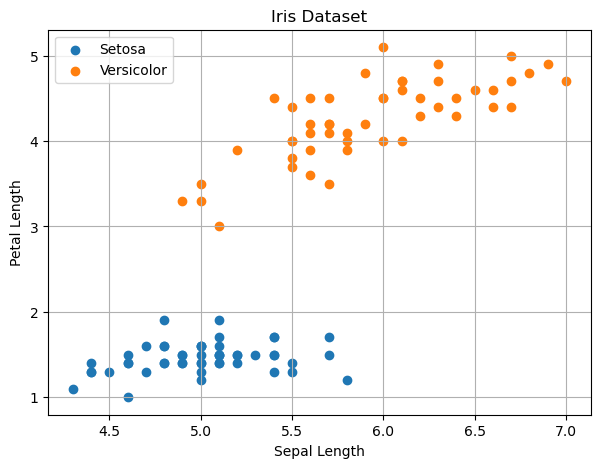

In [ ]:
plt.figure(figsize=(7, 5))

# Class 0: Setosa
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Setosa"
)

# Class 1: Versicolor
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Versicolor"
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.title("Iris Dataset")

plt.legend()
plt.grid(True)

plt.show()

Students should notice that the two classes are approximately linearly separable.

### 6. Split the Dataset

We divide the dataset into:

- 80% training data
- 20% testing data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


### 7. Feature Scaling

The two features may have different numerical ranges.

Standardization transforms the features approximately to:

$$
x' = \frac{x-\mu}{\sigma}
$$

where:

- $\mu$ = mean
- $\sigma$ = standard deviation

In [ ]:
# Create the scaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test = scaler.transform(X_test)

> Important: We fit the scaler only on the training data to avoid data leakage.

### 8. Initialize the Perceptron

The perceptron contains:

```
Input features
     |
Weighted sum
     |
Step activation
     |
Prediction
```

The mathematical equation is:

$$
z = w_1x_1+w_2x_2+b
$$

In [ ]:
# Initialize weights
weights = np.zeros(
    X_train.shape[1]
)

# Initialize bias
bias = 0.0

# Learning rate
learning_rate = 0.01

# Number of training iterations
epochs = 20

print("Initial weights:", weights)
print("Initial bias:", bias)

Initial weights: [0. 0.]
Initial bias: 0.0


### 9. Step Activation Function

The perceptron uses a step function.

$$
f(z)=
\begin{cases}
1 & z \geq 0\\
0 & z < 0
\end{cases}
$$

In [ ]:
def step_function(z):
    """
    Step activation function.

    Parameters
    ----------
    z : float
        Weighted sum of the input features.

    Returns
    -------
    int
        Returns 1 when z >= 0,
        otherwise returns 0.
    """

    if z >= 0:
        return 1

    return 0

### 10. Prediction Function

The prediction process is:

$$
z = w^Tx+b
$$

followed by:

$$
\hat{y}=f(z)
$$

In [ ]:
def predict(x, weights, bias):
    """
    Generate a prediction for one sample.

    Parameters
    ----------
    x : numpy.ndarray
        Input feature vector.

    weights : numpy.ndarray
        Perceptron weight vector.

    bias : float
        Perceptron bias.

    Returns
    -------
    int
        Predicted class.
    """

    # Calculate weighted sum
    z = np.dot(x, weights) + bias

    # Apply step activation
    prediction = step_function(z)

    return prediction

### 11. Train the Perceptron

The perceptron learning rule is:

$$
w_i \leftarrow
w_i+\eta(y-\hat{y})x_i
$$

The bias is updated using:

$$
b \leftarrow
b+\eta(y-\hat{y})
$$

where:

- $w_i$ = weight
- $\eta$ = learning rate
- $y$ = actual label
- $\hat{y}$ = predicted label
- $x_i$ = input feature

In [ ]:
# Store the number of errors for each epoch
error_history = []

for epoch in range(epochs):

    errors = 0

    # Process every training sample
    for xi, target in zip(X_train, y_train):

        # ------------------------------------------------
        # Forward Pass
        # ------------------------------------------------

        prediction = predict(
            xi,
            weights,
            bias
        )

        # ------------------------------------------------
        # Calculate Error
        # ------------------------------------------------

        error = target - prediction

        # ------------------------------------------------
        # Update Weights
        # ------------------------------------------------

        weights += (
            learning_rate
            * error
            * xi
        )

        # ------------------------------------------------
        # Update Bias
        # ------------------------------------------------

        bias += (
            learning_rate
            * error
        )

        # Count incorrectly classified samples
        if error != 0:
            errors += 1

    # Store errors
    error_history.append(errors)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Errors: {errors}"
    )

    # Stop if there are no errors
    if errors == 0:
        break

Epoch 01 | Errors: 3
Epoch 02 | Errors: 0


### 12. Learned Parameters

After training, the perceptron has learned the weights and bias.

In [ ]:
print("\nLearned Parameters")
print("------------------")

print("Weights:", weights)
print("Bias:", bias)


Learned Parameters
------------------
Weights: [0.01203791 0.02829559]
Bias: 0.01


### 13. Plot Training Errors

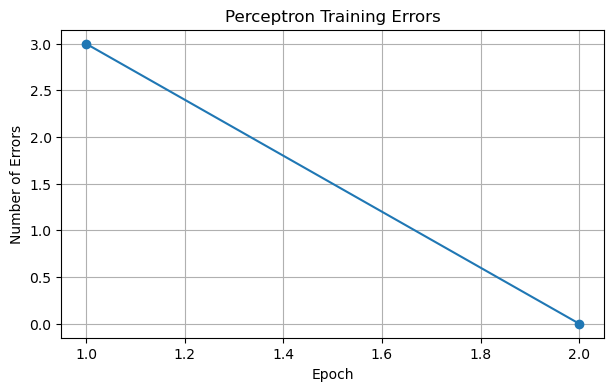

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(error_history) + 1),
    error_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Number of Errors")

plt.title(
    "Perceptron Training Errors"
)

plt.grid(True)

plt.show()

### 14. Test the Perceptron

Now we use the unseen test data.

In [ ]:
# Generate predictions
y_pred = []

for xi in X_test:

    prediction = predict(
        xi,
        weights,
        bias
    )

    y_pred.append(prediction)

# Convert to NumPy array
y_pred = np.array(y_pred)

### 15. Display Predictions

In [ ]:
print("Actual vs Predicted")
print("-------------------")

for actual, predicted in zip(
    y_test,
    y_pred
):

    print(
        f"Actual: {actual} | "
        f"Predicted: {predicted}"
    )

Actual vs Predicted
-------------------
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1


### 16. Calculate Accuracy

Accuracy is:

$$
Accuracy =
\frac{\text{Correct Predictions}}
{\text{Total Predictions}}
$$

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Test Accuracy: {accuracy:.2%}"
)

Test Accuracy: 100.00%


### 17. Confusion Matrix

A confusion matrix shows how many samples were correctly and incorrectly classified.

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0]
 [ 0 10]]


### 18. Visualize the Decision Boundary

The perceptron decision boundary is:

$$
w_1x_1+w_2x_2+b=0
$$

Therefore:

$$
x_2 =
-\frac{w_1x_1+b}{w_2}
$$

In [ ]:
# Generate x1 values
x1_values = np.linspace(
    X_train[:, 0].min() - 1,
    X_train[:, 0].max() + 1,
    100
)

# Calculate x2 values
x2_values = (
    -(weights[0] * x1_values + bias)
    / weights[1]
)

### 19. Plot Decision Boundary

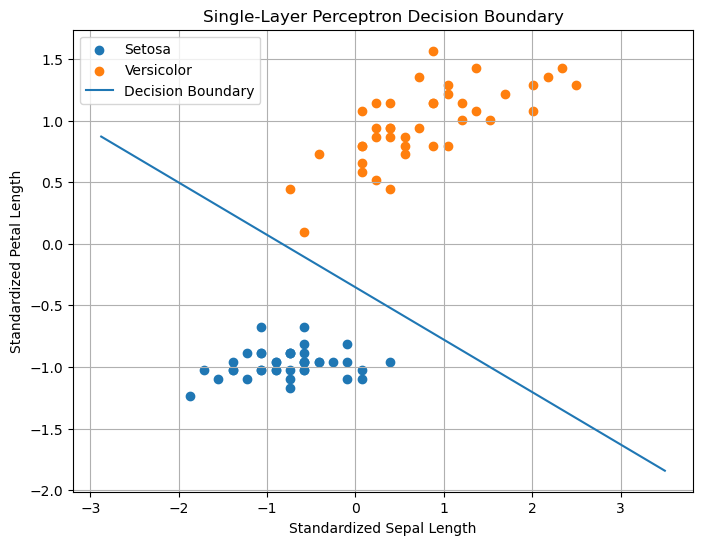

In [ ]:
plt.figure(figsize=(8, 6))

# Training class 0
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Setosa"
)

# Training class 1
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Versicolor"
)

# Decision boundary
plt.plot(
    x1_values,
    x2_values,
    label="Decision Boundary"
)

plt.xlabel("Standardized Sepal Length")
plt.ylabel("Standardized Petal Length")

plt.title(
    "Single-Layer Perceptron Decision Boundary"
)

plt.grid(True)
plt.legend()

plt.show()

### 20. Student Exercise

Train and test the perceptron on a different pair of classes: **Setosa (0) vs. Virginica (1)** instead of Setosa vs. Versicolor.

Steps:

1. Reload the Iris dataset and keep only Setosa and Virginica samples (`mask = (y == 0) | (y == 2)`), then relabel Virginica as 1 (`y[y == 2] = 1`).
2. Use the same two features: sepal length and petal length.
3. Split the data, scale the features, train the perceptron, and print the test accuracy.

Write your code in the cell below.

In [ ]:
# TODO: Implement the perceptron for Setosa vs. Virginica classification.
#
# Hint:
#   mask = (y == 0) | (y == 2)
#   y[y == 2] = 1



### Multi-Layer Perceptron

A Single-Layer Perceptron can only draw a straight-line decision boundary, so it fails whenever the classes are not linearly separable (for example, Versicolor and Virginica overlap on several features).

A Multi-Layer Perceptron (MLP) adds one or more **hidden layers** between the input and the output. Each hidden neuron applies a non-linear activation function, which lets the network bend its decision boundary and separate classes that a single-layer perceptron cannot.

For this notebook, we reuse the Iris dataset, but now we classify **all three species at once** (Setosa, Versicolor, Virginica) using the same two features as before (sepal length, petal length), so the improvement over the single-layer perceptron is easy to see.

### 1. Import Required Libraries

In [ ]:
# ============================================================
# MULTI-LAYER PERCEPTRON
# Multi-Class Classification using the Iris Dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

### 2. Load the Public Dataset

This time we keep **all three classes**:

```
0 -> Setosa
1 -> Versicolor
2 -> Virginica
```

and, as before, only two features for visualization: sepal length and petal length.

In [ ]:
# Load the Iris dataset
iris = load_iris()

# Use two features: sepal length, petal length
X = iris.data[:, [0, 2]]

# Use all three classes
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:", iris.target_names)

Feature shape: (150, 2)
Target shape: (150,)
Class names: ['setosa' 'versicolor' 'virginica']


### 3. One-Hot Encode the Labels

The output layer will have **three neurons**, one per class. To train against three outputs at once, each label is converted into a one-hot vector:

```
0 (Setosa)     -> [1, 0, 0]
1 (Versicolor) -> [0, 1, 0]
2 (Virginica)  -> [0, 0, 1]
```

In [ ]:
n_classes = len(iris.target_names)

# One-hot encode: row i has a 1 in column y[i], zeros elsewhere
y_onehot = np.eye(n_classes)[y]

print("y_onehot shape:", y_onehot.shape)
print("First 3 labels:     ", y[:3])
print("First 3 one-hot rows:\n", y_onehot[:3])

y_onehot shape: (150, 3)
First 3 labels:      [0 0 0]
First 3 one-hot rows:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


### 4. Visualize the Dataset

Notice that Setosa is still clearly separated, but Versicolor and Virginica overlap - this is the part a single-layer perceptron cannot handle.

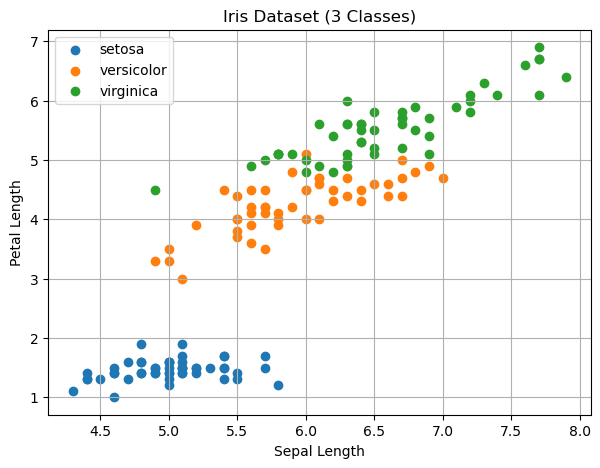

In [ ]:
plt.figure(figsize=(7, 5))

for class_value, class_name in enumerate(iris.target_names):
    plt.scatter(
        X[y == class_value, 0],
        X[y == class_value, 1],
        label=class_name
    )

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.title("Iris Dataset (3 Classes)")

plt.legend()
plt.grid(True)

plt.show()

### 5. Split the Dataset

We split the features and the one-hot labels together, using the original integer labels only to keep the class balance (`stratify=y`).

In [ ]:
X_train, X_test, y_train, y_test, y_train_onehot, y_test_onehot = train_test_split(
    X,
    y,
    y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


### 6. Feature Scaling

As with the single-layer perceptron, we standardize the features, fitting the scaler only on the training data.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 7. Initialize the MLP

The network now has one hidden layer:

```
Input features (2)
     |
Hidden layer (8 neurons, sigmoid)
     |
Output layer (3 neurons, softmax)
     |
Prediction
```

Unlike the single-layer perceptron, the weights **cannot** start at zero - if every hidden neuron started identical, they would all learn the same thing. So we initialize them with small random values instead.

In [ ]:
n_features = X_train.shape[1]
n_hidden = 8
n_outputs = n_classes

rng = np.random.default_rng(42)

# Weights and biases: input -> hidden
W1 = rng.normal(loc=0.0, scale=0.5, size=(n_features, n_hidden))
b1 = np.zeros(n_hidden)

# Weights and biases: hidden -> output
W2 = rng.normal(loc=0.0, scale=0.5, size=(n_hidden, n_outputs))
b2 = np.zeros(n_outputs)

learning_rate = 0.5
epochs = 3000

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (2, 8)
W2 shape: (8, 3)


### 8. Activation Functions

The hidden layer uses the **sigmoid** function, which is smooth and differentiable (needed for training with gradient descent):

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

The output layer uses **softmax**, which turns the three output scores into probabilities that sum to 1:

$$
\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

In [ ]:
def sigmoid(z):
    """Sigmoid activation, used in the hidden layer."""
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    """
    Derivative of sigmoid, expressed in terms of its OWN output `a`
    (a = sigmoid(z)), which is convenient during backpropagation.
    """
    return a * (1 - a)


def softmax(z):
    """Softmax activation, used in the output layer."""
    # Subtract the row max for numerical stability (does not change the result)
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

### 9. Forward Propagation

The forward pass computes, layer by layer:

$$
Z_1 = XW_1+b_1 \qquad A_1=\sigma(Z_1)
$$

$$
Z_2 = A_1W_2+b_2 \qquad A_2=\text{softmax}(Z_2)
$$

`A_2` is the network's predicted probability for each class.

In [ ]:
def forward(X, W1, b1, W2, b2):
    """
    Run the forward pass and return every intermediate value needed
    for backpropagation.
    """

    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

### 10. Train the MLP

Training repeats three steps every epoch:

1. **Forward pass** - compute predictions `A2` for the whole training set.
2. **Loss** - measure how wrong the predictions are with categorical cross-entropy:

$$
L = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{3} y_{ik}\log(\hat{y}_{ik})
$$

3. **Backward pass** - use the chain rule to compute how much each weight contributed to the error, then nudge every weight a little in the direction that reduces the loss:

$$
W \leftarrow W - \eta \frac{\partial L}{\partial W}
\qquad
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

Because we use softmax together with cross-entropy loss, the gradient at the output layer simplifies to `A2 - y_true`.

In [ ]:
loss_history = []

m = X_train.shape[0]

for epoch in range(epochs):

    # ------------------------------------------------
    # Forward Pass
    # ------------------------------------------------
    Z1, A1, Z2, A2 = forward(X_train, W1, b1, W2, b2)

    # ------------------------------------------------
    # Loss (categorical cross-entropy)
    # ------------------------------------------------
    epsilon = 1e-9  # avoids log(0)
    loss = -np.mean(np.sum(y_train_onehot * np.log(A2 + epsilon), axis=1))
    loss_history.append(loss)

    # ------------------------------------------------
    # Backward Pass
    # ------------------------------------------------

    # Output layer gradients
    dZ2 = A2 - y_train_onehot
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.mean(dZ2, axis=0)

    # Hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = np.dot(X_train.T, dZ1) / m
    db1 = np.mean(dZ1, axis=0)

    # ------------------------------------------------
    # Update Weights and Biases
    # ------------------------------------------------
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1:04d} | Loss: {loss:.4f}")

Epoch 0500 | Loss: 0.1245
Epoch 1000 | Loss: 0.0870
Epoch 1500 | Loss: 0.0799
Epoch 2000 | Loss: 0.0772
Epoch 2500 | Loss: 0.0759
Epoch 3000 | Loss: 0.0750


### 11. Learned Parameters

After training, the network has learned two sets of weights and biases: one between the input and hidden layer, and one between the hidden and output layer.

In [ ]:
print("Learned Parameters")
print("-------------------")
print("W1 shape:", W1.shape)
print("b1:", b1)
print("W2 shape:", W2.shape)
print("b2:", b2)

Learned Parameters
-------------------
W1 shape: (2, 8)
b1: [-2.37738353  1.91964051 -0.02209805  3.17741849 -0.66093373  1.15877897
  0.14724239 -0.22622177]
W2 shape: (8, 3)
b2: [-0.05466922  0.20804336 -0.15337414]


### 12. Plot Training Loss

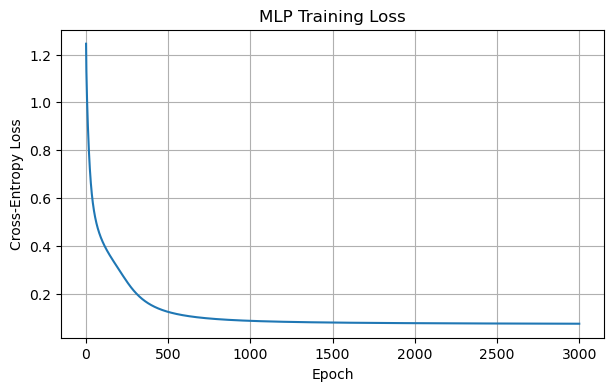

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(range(1, len(loss_history) + 1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.title("MLP Training Loss")

plt.grid(True)

plt.show()

### 13. Test the MLP

To turn the network's probabilities into a class prediction, we take the class with the highest probability (`argmax`).

In [ ]:
def predict(X, W1, b1, W2, b2):
    """Predict class labels (0, 1, or 2) for one or more samples."""
    _, _, _, A2 = forward(X, W1, b1, W2, b2)
    return np.argmax(A2, axis=1)


y_pred = predict(X_test, W1, b1, W2, b2)

### 14. Display Predictions

In [ ]:
print("Actual vs Predicted")
print("-------------------")

for actual, predicted in zip(y_test, y_pred):
    print(
        f"Actual: {iris.target_names[actual]:<10} | "
        f"Predicted: {iris.target_names[predicted]}"
    )

Actual vs Predicted
-------------------
Actual: setosa     | Predicted: setosa
Actual: virginica  | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: setosa     | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: setosa     | Predicted: setosa
Actual: setosa     | Predicted: setosa
Actual: virginica  | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: virginica  | Predicted: virginica
Actual: virginica  | Predicted: virginica
Actual: virginica  | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: setosa     | Predicted: setosa
Actual: setosa     | Predicted: setosa
Actual: setosa     | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: virginica  | Predicted: virginica
Actual: setosa     | Predicted: setosa
Actual: virginica  | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: vi

### 15. Calculate Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 100.00%


### 16. Confusion Matrix

Because there are three classes, the confusion matrix is now 3x3. Any mistakes should mostly appear between Versicolor and Virginica, the two classes that overlap.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


### 17. Visualize the Decision Boundary

Instead of a single straight line (as with the perceptron), we evaluate the network on a fine grid of points and color each point by its predicted class. This reveals the curved, non-linear regions the hidden layer has learned.

In [ ]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid_points, W1, b1, W2, b2)
Z = Z.reshape(xx.shape)

### 18. Plot Decision Boundary

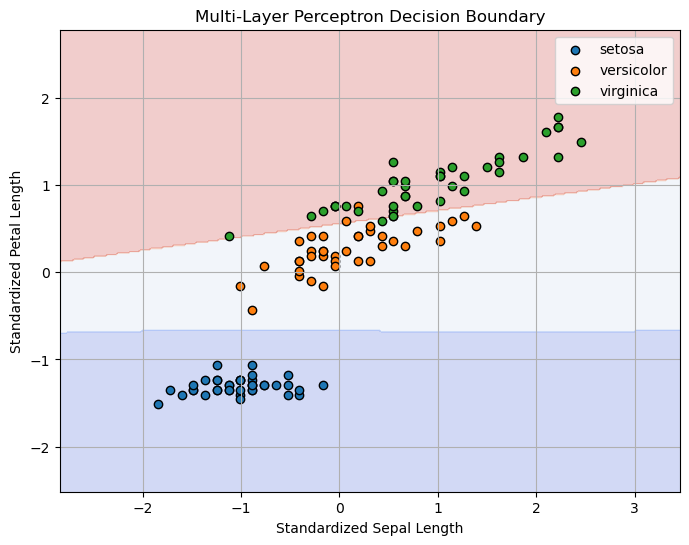

In [ ]:
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)

for class_value, class_name in enumerate(iris.target_names):
    plt.scatter(
        X_train[y_train == class_value, 0],
        X_train[y_train == class_value, 1],
        label=class_name,
        edgecolor="k"
    )

plt.xlabel("Standardized Sepal Length")
plt.ylabel("Standardized Petal Length")

plt.title("Multi-Layer Perceptron Decision Boundary")

plt.grid(True)
plt.legend()

plt.show()

### 19. Student Exercise

Change the number of hidden neurons from `n_hidden = 8` to `n_hidden = 2`, retrain the network, and re-plot the decision boundary.

Does a hidden layer with only 2 neurons still separate Versicolor from Virginica as well as before? Write your code in the cell below.

In [ ]:
# TODO: Set n_hidden = 2, re-initialize W1/b1/W2/b2, retrain the MLP,
# and re-plot the decision boundary to compare with n_hidden = 8.
